# DATA CLEANING

1- Missing Values

2- Duplicates

3- Outlier Detection

4- Plotting


In [239]:
## Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [240]:
## Importimg dataset
df = pd.read_csv("Student_data.csv")
df.head()

,gender,age,parental_education,family_income,internet_access,previous_exam_score,attendance_rate,homework_completion_rate,class_participation_score,number_of_absences,extra_curricular_involvement,learning_hours_per_week,tutor_support,final_exam_score
0,Male,14,Diploma,29591.84,Yes,93.25,91.01,76.56,9.52,1,Moderate,12.08,No,100.00
1,Male,16,Diploma,35222.46,Yes,85.06,83.85,64.82,3.42,2,Moderate,11.81,Yes,80.81
2,Male,14,Diploma,29730.93,Yes,79.93,86.71,75.02,3.75,1,Low,11.08,Yes,77.96
3,Female,15,Diploma,29074.09,Yes,98.94,88.04,55.50,6.95,0,Moderate,6.65,Yes,98.86
4,Male,19,Graduate,42305.33,Yes,64.54,61.22,98.85,6.03,5,Moderate,9.26,No,64.64


In [241]:
df.shape
'''
There are total of 1000 rows and 14 columns
'''

'\nThere are total of 1000 rows and 14 columns\n'

In [242]:
df.columns

Index(['gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'previous_exam_score', 'attendance_rate',
       'homework_completion_rate', 'class_participation_score',
       'number_of_absences', 'extra_curricular_involvement',
       'learning_hours_per_week', 'tutor_support', 'final_exam_score'],
      dtype='str')

### 1. Checking Missing Values

In [243]:
df.isna().sum()

gender                            0
age                               0
parental_education                0
family_income                     0
internet_access                   0
previous_exam_score               0
attendance_rate                   0
homework_completion_rate          0
class_participation_score         0
number_of_absences                0
extra_curricular_involvement    372
learning_hours_per_week           0
tutor_support                     0
final_exam_score                  0
dtype: int64

In [244]:
df['extra_curricular_involvement'].value_counts()

extra_curricular_involvement
Low         311
Moderate    224
High         93
Name: count, dtype: int64

In [245]:
df['extra_curricular_involvement'] = df['extra_curricular_involvement'].fillna(df['extra_curricular_involvement'].mode()[0])

In [246]:
df.isna().sum()

gender                          0
age                             0
parental_education              0
family_income                   0
internet_access                 0
previous_exam_score             0
attendance_rate                 0
homework_completion_rate        0
class_participation_score       0
number_of_absences              0
extra_curricular_involvement    0
learning_hours_per_week         0
tutor_support                   0
final_exam_score                0
dtype: int64

### 2. Outlier Detection

<Axes: ylabel='previous_exam_score'>

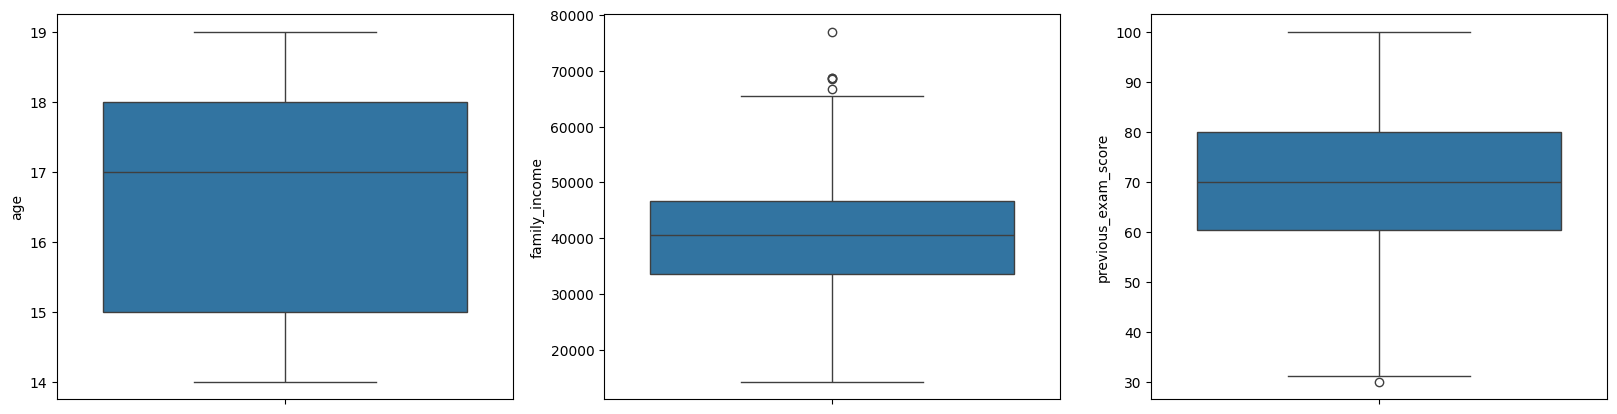

In [247]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(df['age'])

plt.subplot(1,3,2)
sns.boxplot(df['family_income'])

plt.subplot(1,3,3)
sns.boxplot(df['previous_exam_score'])


<Axes: ylabel='class_participation_score'>

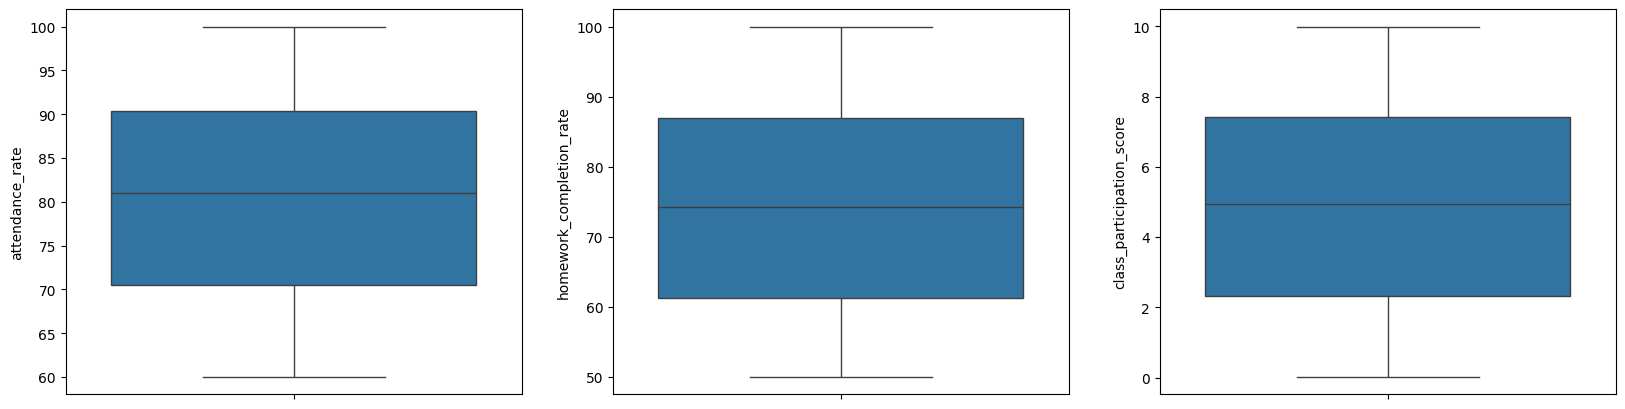

In [248]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(df['attendance_rate'])

plt.subplot(1,3,2)
sns.boxplot(df['homework_completion_rate'])

plt.subplot(1,3,3)
sns.boxplot(df['class_participation_score'])

<Axes: ylabel='final_exam_score'>

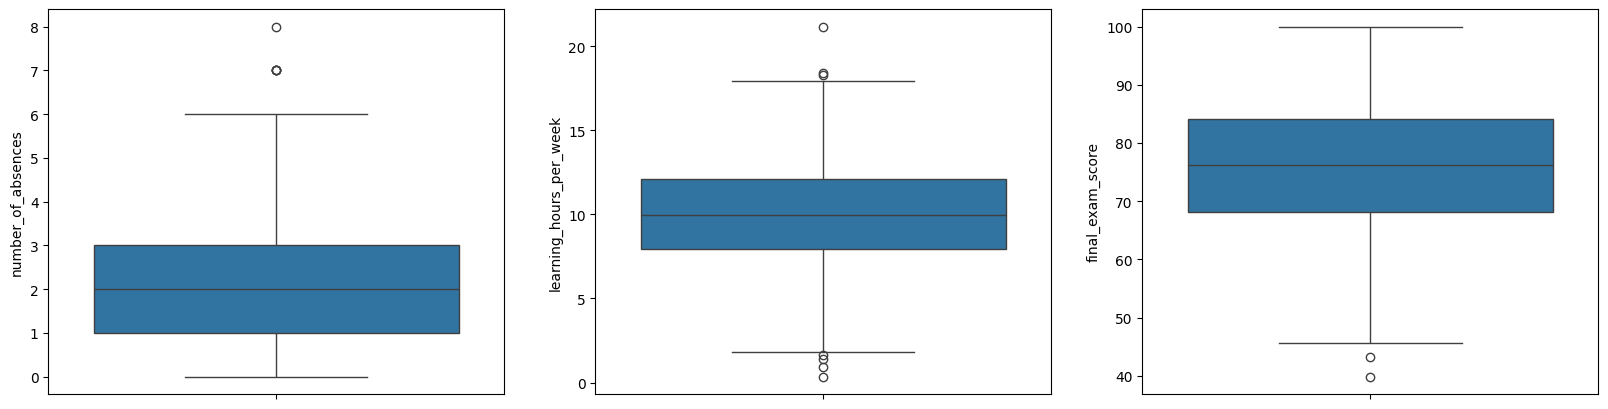

In [249]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.boxplot(df['number_of_absences'])

plt.subplot(1,3,2)
sns.boxplot(df['learning_hours_per_week'])

plt.subplot(1,3,3)
sns.boxplot(df['final_exam_score'])

In [250]:
num_features = [feature for feature in df.columns if df[feature].dtype == 'float' or df[feature].dtype=='int']

cat_features = [feature for feature in df.columns if feature not in num_features]
print(num_features)
print(cat_features)

['age', 'family_income', 'previous_exam_score', 'attendance_rate', 'homework_completion_rate', 'class_participation_score', 'number_of_absences', 'learning_hours_per_week', 'final_exam_score']
['gender', 'parental_education', 'internet_access', 'extra_curricular_involvement', 'tutor_support']


In [251]:
## Using IQR method

for i in num_features:
    Q1 = df[num_features].quantile(0.25)
    Q2 = df[num_features].median()
    Q3 = df[num_features].quantile(0.75)

    IQR = Q3-Q1

    lower_range = Q1 - (1.5*IQR)
    upper_range = Q3 + (1.5*IQR)

    df[num_features] = df[num_features].clip(lower=lower_range,upper=upper_range,axis=1)


In [252]:
df.shape

(1000, 14)

### 3. Checking Duplicates

In [253]:
df.duplicated().sum()

np.int64(0)

### 4. Plots

In [254]:
df[num_features].corr()

,age,family_income,previous_exam_score,attendance_rate,homework_completion_rate,class_participation_score,number_of_absences,learning_hours_per_week,final_exam_score
age,1.000000,-0.025128,-0.003327,-0.017159,0.034844,-0.013589,0.019138,0.029844,-0.006523
family_income,-0.025128,1.000000,0.006805,-0.004529,0.016435,0.008924,-0.026529,-0.003430,0.007513
previous_exam_score,-0.003327,0.006805,1.000000,0.009626,0.020631,0.022894,-0.013918,-0.011533,0.492771
attendance_rate,-0.017159,-0.004529,0.009626,1.000000,-0.002420,0.018264,-0.102378,-0.008162,0.229196
homework_completion_rate,0.034844,0.016435,0.020631,-0.002420,1.000000,-0.025077,0.051340,-0.032247,0.096671
class_participation_score,-0.013589,0.008924,0.022894,0.018264,-0.025077,1.000000,0.004592,-0.033650,0.512840
number_of_absences,0.019138,-0.026529,-0.013918,-0.102378,0.051340,0.004592,1.000000,0.030446,-0.190696
learning_hours_per_week,0.029844,-0.003430,-0.011533,-0.008162,-0.032247,-0.033650,0.030446,1.000000,0.368200
final_exam_score,-0.006523,0.007513,0.492771,0.229196,0.096671,0.512840,-0.190696,0.368200,1.000000


<Axes: >

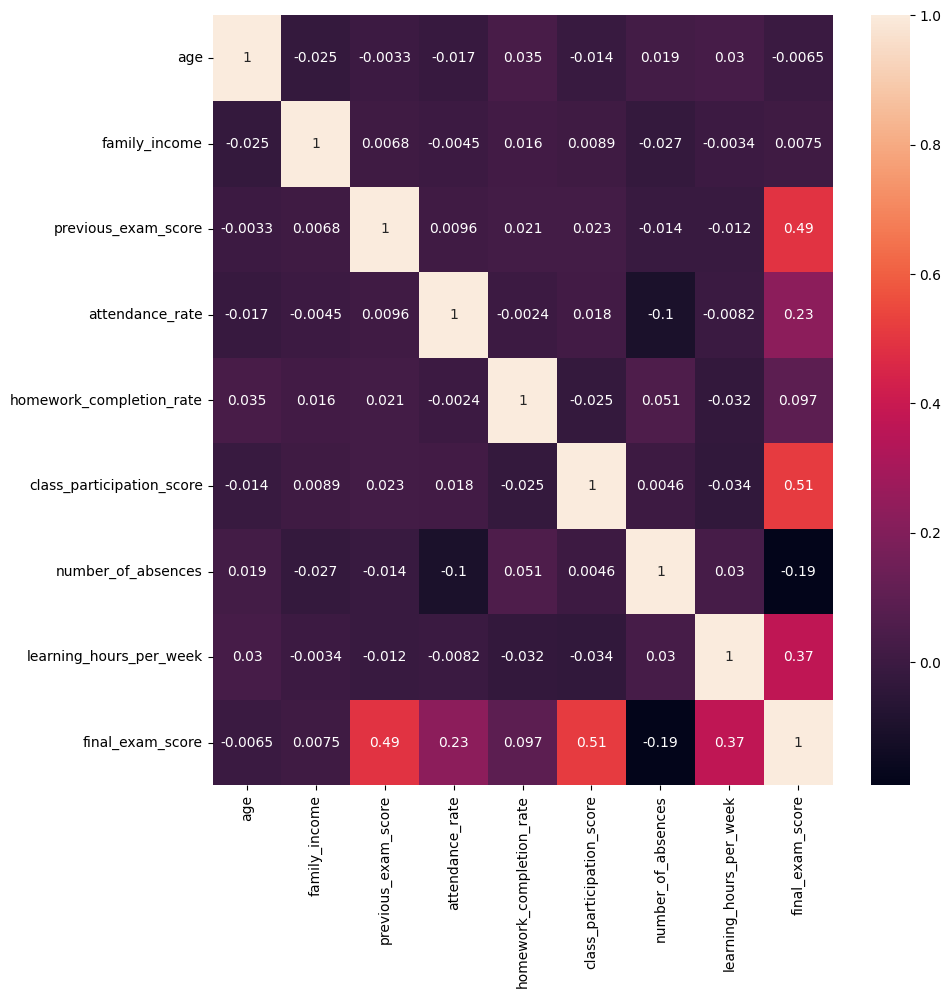

In [255]:
plt.figure(figsize=(10,10))
sns.heatmap(df[num_features].corr(),annot=True)

In [256]:
df.to_csv('Student_data_cleaned.csv',index=False)